In [1]:
import functools
import warnings

import botocore
import boto3
from cliffs_delta import cliffs_delta
from iterpop import iterpop as ip
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmp9m8c
interpreter: 3.10.12 (main, Jun 22 2026, 18:55:27) [GCC 11.4.0]
notebook name: 2025-12-11-replaysmutagenized08-early
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-11-replaysmutagenized08-early.ipynb
revision: bdac574
timestamp: 2026-08-15T21:39:29Z00:00

IPython==7.16.1
packaging==26.2


In [4]:
teeplot_subdir = "2025-11-23-replaysmutagenized08"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions/stage=2+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
dfs = []
for bucket in [
    "prq49-restint-mut08-selfmut00bb-rep10-step00",
    "prq49-restint-mut08-selfmut00bb-rep11-step00",
    "prq49-restint-mut08-selfmut00bb-rep12-step00",
    "prq49-restint-mut08-selfmut00bb-rep13-step00",
    "prq49-restint-mut08-selfmut00bb-rep14-step00",
    "prq49-restint-mut08-selfmut00bb-rep15-step00",
    "prq49-restint-mut08-truemut00bb-rep10-step00",
    "prq49-restint-mut08-truemut00bb-rep11-step00",
    "prq49-restint-mut08-truemut00bb-rep12-step00",
    "prq49-restint-mut08-truemut00bb-rep13-step00",
    "prq49-restint-mut08-truemut00bb-rep14-step00",
    "prq49-restint-mut08-truemut00bb-rep15-step00",
]:
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm(range(35)):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/variant-competitions/stage=3+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df = df[df["Competition Series"] == 16005]
            df = df[df["genome variation"] != "master"].copy()
            df = df.groupby("genome variation").mean(numeric_only=True).reset_index()
            # print(f"{bucket=}, {stint=}, {len(df)=}, {kind=}, {step=}")
            df["Stint"] = stint
            dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)

            df = df.copy()
            df["bucket"] = bucket
            df["Source Stint"] = stint - step
            df["kind"] = kind
            dfs.append(df)
        except:
            print(f"Skipping {bucket=}, {stint=}")


 29%|██▊       | 10/35 [00:08<00:17,  1.46it/s]

Skipping bucket='prq49-restint-mut08-truemut00bb-rep13-step00', stint=9


100%|██████████| 35/35 [00:30<00:00,  1.15it/s]


In [8]:
df = pd.concat(dfs)


In [9]:
df.to_csv("replays-mutagenized.csv")


In [10]:
pd.options.display.max_columns = None
df["target idx"] = df["genome variation"].str.replace("%Nop-0", "").str.replace("i", "").astype(int)


In [11]:
dfx = df[
    df["Root ID"] == 1
].groupby(["Stint", "bucket", "Source Stint", "kind"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "target idx": "max",
        "genome variation": "count",
    },
)
dfx


Is More Fit  \
Stint bucket                                       Source Stint kind                       
0     prq49-restint-mut08-selfmut00bb-rep10-step00 -1           selfmut00bb            0   
      prq49-restint-mut08-selfmut00bb-rep11-step00 -1           selfmut00bb            0   
      prq49-restint-mut08-selfmut00bb-rep12-step00 -1           selfmut00bb            2   
      prq49-restint-mut08-selfmut00bb-rep13-step00 -1           selfmut00bb            1   
      prq49-restint-mut08-selfmut00bb-rep14-step00 -1           selfmut00bb            0   
...                                                                                  ...   
34    prq49-restint-mut08-truemut00bb-rep11-step00  33          truemut00bb            2   
      prq49-restint-mut08-truemut00bb-rep12-step00  33          truemut00bb            6   
      prq49-restint-mut08-truemut00bb-rep13-step00  33          truemut00bb            2   
      prq49-restint-mut08-truemut00bb-rep14-step00  33          truemut00bb            1   
      prq49-restint-mut08-truemut00bb-rep15-step00  33          truemut00bb           12   

                                                                             Is Less Fit  \
Stint bucket                                       Source Stint kind                       
0     prq49-restint-mut08-selfmut00bb-rep10-step00 -1           selfmut00bb            8   
      prq49-restint-mut08-selfmut00bb-rep11-step00 -1           selfmut00bb           16   
      prq49-restint-mut08-selfmut00bb-rep12-step00 -1           selfmut00bb            9   
      prq49-restint-mut08-selfmut00bb-rep13-step00 -1           selfmut00bb            3   
      prq49-restint-mut08-selfmut00bb-rep14-step00 -1           selfmut00bb           10   
...                                                                                  ...   
34    prq49-restint-mut08-truemut00bb-rep11-step00  33          truemut00bb           31   
      prq49-restint-mut08-truemut00bb-rep12-step00  33          truemut00bb           23   
      prq49-restint-mut08-truemut00bb-rep13-step00  33          truemut00bb           27   
      prq49-restint-mut08-truemut00bb-rep14-step00  33          truemut00bb           40   
      prq49-restint-mut08-truemut00bb-rep15-step00  33          truemut00bb           27   

                                                                             Is Neutral  \
Stint bucket                                       Source Stint kind                      
0     prq49-restint-mut08-selfmut00bb-rep10-step00 -1           selfmut00bb          12   
      prq49-restint-mut08-selfmut00bb-rep11-step00 -1           selfmut00bb          10   
      prq49-restint-mut08-selfmut00bb-rep12-step00 -1           selfmut00bb          24   
      prq49-restint-mut08-selfmut00bb-rep13-step00 -1           selfmut00bb          52   
      prq49-restint-mut08-selfmut00bb-rep14-step00 -1           selfmut00bb          21   
...                                                                                 ...   
34    prq49-restint-mut08-truemut00bb-rep11-step00  33          truemut00bb          96   
      prq49-restint-mut08-truemut00bb-rep12-step00  33          truemut00bb         687   
      prq49-restint-mut08-truemut00bb-rep13-step00  33          truemut00bb          59   
      prq49-restint-mut08-truemut00bb-rep14-step00  33          truemut00bb          61   
      prq49-restint-mut08-truemut00bb-rep15-step00  33          truemut00bb          63   

                                                                             target idx  \
Stint bucket                                       Source Stint kind                      
0     prq49-restint-mut08-selfmut00bb-rep10-step00 -1           selfmut00bb         150   
      prq49-restint-mut08-selfmut00bb-rep11-step00 -1           selfmut00bb         204   
      prq49-restint-mut08-selfmut00bb-rep12-step00 -1           selfmut00bb         120   
      prq49-restint-mut08-selfmut00bb-rep13-

In [12]:
dfx = dfx.reset_index(drop=False)
dfx["Step"] = dfx["Stint"] - dfx["Source Stint"]


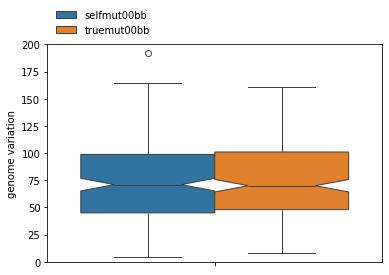

In [13]:
ax = sns.boxplot(
    data=dfx[
        (dfx["Step"] > 0)
    ],
    # x="Stint",
    y="genome variation",
    hue="kind",
    notch=True,
    # legend=False,
)
ax.set_ylim(0, 200)
sns.move_legend(
    ax,
    "lower left",
    bbox_to_anchor=(0, 1),
    title="",
    frameon=False,
)


In [14]:
# dfx["epoch"] = dfx["Stint"].apply(
#     lambda stint: (stint >= 15) + (stint >= 20) + (stint >= 25) + (stint >= 30)
# )
dfx["epoch"] = dfx["Stint"].apply(
    lambda stint: (stint >= 15) + (stint >= 25)
)


teeplots/density-norm=width+hue=kind+viz=violinplot+x=epoch+y=is-less-fit+ext=.pdf
teeplots/density-norm=width+hue=kind+viz=violinplot+x=epoch+y=is-less-fit+ext=.png


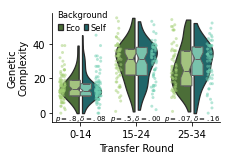

In [15]:
light_palette=[
    "#a3cf73",
    "#6dceb1",
]
dark_palette=[
    "#4a772f",
    "#137177",
]

with tp.teed(
    sns.violinplot,
    data=dfx[
        (dfx["Step"] > 0)
    ].replace(
        {"kind": {
            "selfmut00bb": "Self",
            "truemut00bb": "Eco",
        }}
    ),
    x="epoch",
    y="Is Less Fit",
    hue="kind",
    hue_order=["Eco", "Self"],
    cut=0,
    density_norm="width",
    inner=None,
    gap=0.15,
    palette=dark_palette,
    split=True,
    zorder=-10,
) as ax:
    ax.figure.set_size_inches(3, 2)
    sns.boxplot(
        data=dfx[
            (dfx["Step"] > 0)
        ],
        x="epoch",
        y="Is Less Fit",
        hue="kind",
        hue_order=[None, "truemut00bb", "selfmut00bb", None],
        ax=ax,
        legend=False,
        notch=True,
        showfliers=False,
        palette=["white", *light_palette, "white"],
        whis=0.0,
    )
    sns.stripplot(
        data=dfx[
            (dfx["Step"] > 0)
        ],
        x="epoch",
        y="Is Less Fit",
        hue="kind",
        hue_order=["truemut00bb", None, None, None, "selfmut00bb"],
        alpha=0.5,
        ax=ax,
        palette=[light_palette[0], "black", "black", "black", light_palette[1]],
        dodge=True,
        jitter=0.25,
        legend=False,
        size=3,
    )
    sns.barplot
    sns.move_legend(
        ax,
        "lower left",
        bbox_to_anchor=(0, 1),
        title="",
        frameon=False,
    )
    sns.despine(ax=ax)
    ax.set_xticklabels(
        [
            "0-14",
            "15-24",
            "25-34",
        ],
    )
    ax.set_xlabel("Transfer Round")
    ax.set_ylabel("Genetic\nComplexity")
    sns.move_legend(
        ax,
        "upper left",
        bbox_to_anchor=(-0.015, 1.1),
        columnspacing=0.5,
        title="Background",
        frameon=False,
        fontsize="small",
        handlelength=0.5,
        handletextpad=0.3,
        ncol=2,
        title_fontsize="small",
    )
    ax.set_ylim(-5, None)
    ax.text(
        0,
        0,
        ha="center",
        va="top",
        s="$p=.8,\delta=.08$",
        fontsize="x-small",
    )
    ax.text(
        1,
        0,
        ha="center",
        va="top",
        s="$p=.5,\delta=.00$",
        fontsize="x-small",
    )
    ax.text(
        2,
        0,
        ha="center",
        va="top",
        s="$p=.07,\delta=.16$",
        fontsize="x-small",
    )


In [16]:
res = []
for epoch, group in dfx[
    (dfx["Step"] > 0)
].groupby("epoch"):
    mwstat = scipy_stats.mannwhitneyu(
        group[
            (group["Step"] > 0) & (group["kind"] == "truemut00bb")
        ]["Is Less Fit"],
        group[
            (group["Step"] > 0) & (group["kind"] == "selfmut00bb")
        ]["Is Less Fit"],
        alternative="less",
    )
    (delta, effect_size) = cliffs_delta(
        group[
            (group["Step"] > 0) & (group["kind"] == "truemut00bb")
        ]["Is Less Fit"],
        group[
            (group["Step"] > 0) & (group["kind"] == "selfmut00bb")
        ]["Is Less Fit"],
    )
    res.append({
        "epoch": epoch,
        "U Statistic": mwstat.statistic,
        "p-value": mwstat.pvalue,
        "Cliff's Delta": delta,
        "Effect Size": effect_size,
    })

pd.DataFrame(res)


,epoch,U Statistic,p-value,Cliff's Delta,Effect Size
0,0,4329.5,0.826184,0.081024,negligible
1,1,1804.5,0.510475,0.002500,negligible
2,2,1517.5,0.069316,-0.156944,small


In [17]:
palette = [sns.color_palette("Dark2")[0], sns.color_palette("Dark2")[4]]


teeplots/hue=kind+style=kind+viz=lineplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/hue=kind+style=kind+viz=lineplot+x=stint+y=is-less-fit+ext=.png


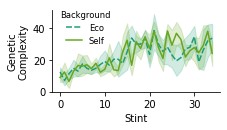

In [18]:
with tp.teed(
    sns.lineplot,
    data=dfx[
        (dfx["Step"] > 0)
    ].replace(
        {"kind": {
            "selfmut00bb": "Self",
            "truemut00bb": "Eco",
        }},
    ),
    x="Stint",
    y="Is Less Fit",
    hue="kind",
    hue_order=["Eco", "Self"],
    style="kind",
    palette=palette,
) as ax:
    sns.move_legend(
        ax,
        "upper left",
        bbox_to_anchor=(0.0, 1.1),
        columnspacing=0.5,
        title="Background",
        frameon=False,
        fontsize="small",
        ncol=1,
        title_fontsize="small",
    )
    sns.despine(ax=ax)
    ax.set_ylabel("Genetic\nComplexity")
    ax.figure.set_size_inches(3, 1.5)
